# Superstore Sales Analysis with Python

## Project Overview

This project analyzes the Sample Superstore dataset using Python.

The main goals are to:
- explore and clean the data
- analyze sales and profitability
- investigate discounts and their relationship with profit
- analyze customers and products
- identify trends and patterns
- examine correlations and outliers
- generate business insights and recommendations

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

In [1]:
import pandas as pd

df = pd.read_excel("Sample - Superstore.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 1. Data Overview

I reviewed the structure of the dataset, including the number of rows, columns, and data types.

This helps me understand the dataset before starting the analysis.

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.dtypes

Rows: 9994
Columns: 21


Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

### Missing Values

I checked each column for missing values to identify potential data quality issues before performing the analysis.

In [3]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

**Result:** No missing values were found in the dataset.

### Duplicate Records

I checked the dataset for duplicate rows to make sure the analysis would not be affected by repeated records.

In [4]:
df.duplicated().sum()

np.int64(0)

**Result:** No duplicate rows were found.

## 2. Descriptive Statistics

I used descriptive statistics to understand the distribution and overall range of the main numeric variables.

The analysis includes Sales, Quantity, Discount, and Profit.

In [5]:
df[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


Matplotlib is building the font cache; this may take a moment.


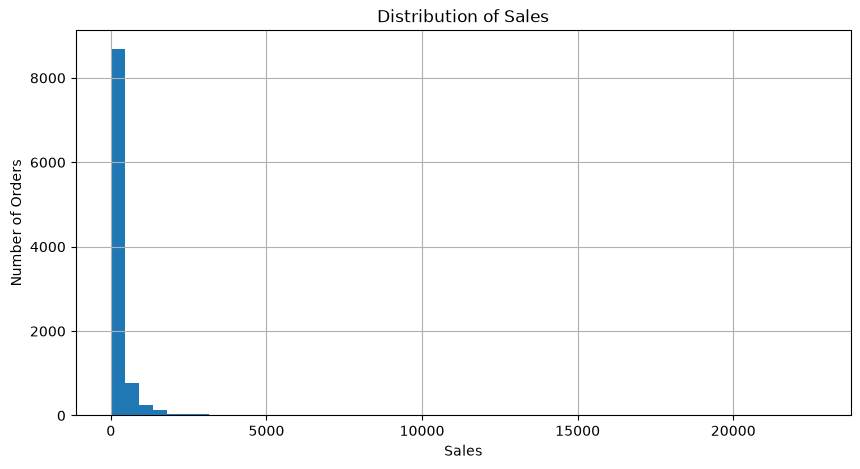

In [6]:
import matplotlib.pyplot as plt

df["Sales"].hist(bins=50, figsize=(10, 5))

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Number of Orders")
plt.show()

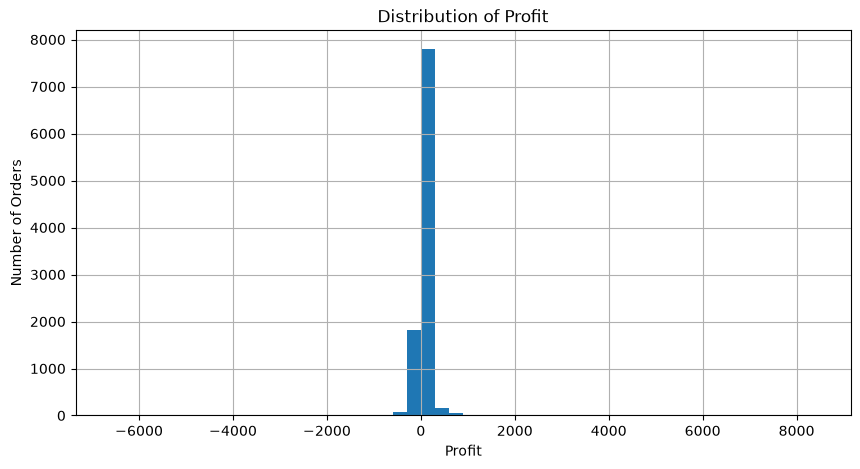

In [7]:
df["Profit"].hist(bins=50, figsize=(10, 5))

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.show()

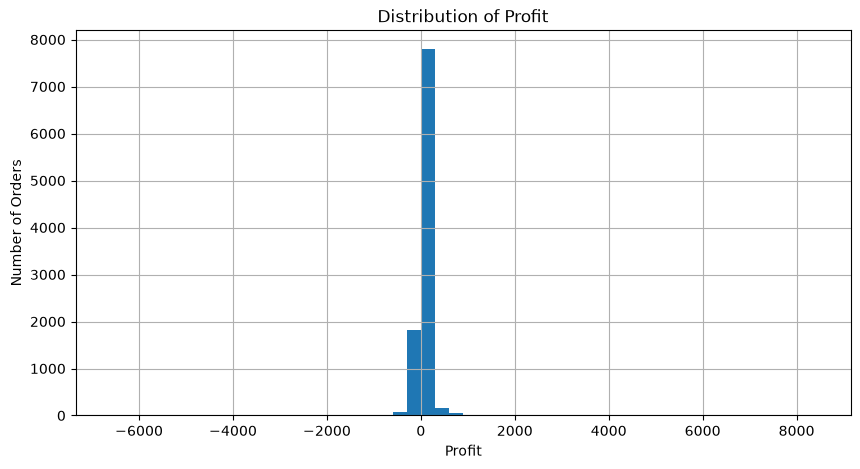

In [8]:
df["Profit"].hist(bins=50, figsize=(10, 5))

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Number of Orders")
plt.show()

In [9]:
df.groupby("Discount")["Profit"].mean()

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64

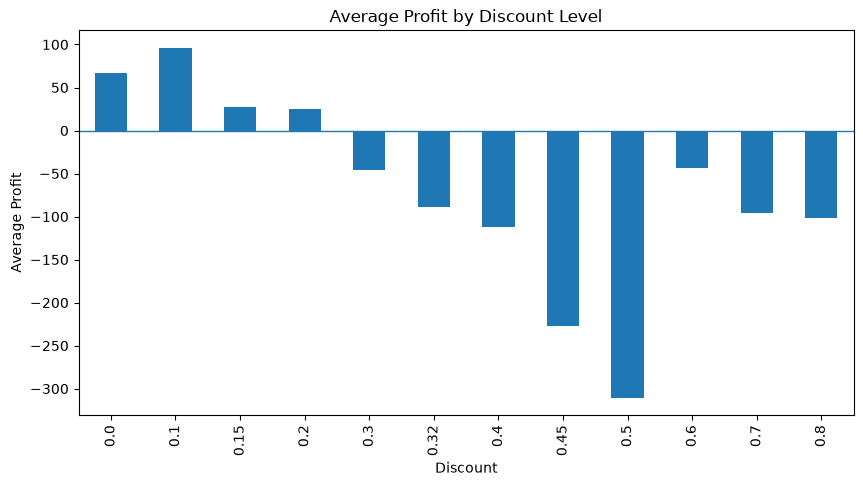

In [10]:
df.groupby("Discount")["Profit"].mean().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.axhline(0, linewidth=1)
plt.show()

In [11]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [12]:
category_performance = df.groupby("Category")[["Sales", "Profit"]].sum()

category_performance

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [13]:
category_performance["Profit_Margin"] = (
    category_performance["Profit"] /
    category_performance["Sales"] * 100
)

category_performance

,Sales,Profit,Profit_Margin
Category,,,
Furniture,741999.7953,18451.2728,2.486695
Office Supplies,719047.0320,122490.8008,17.035158
Technology,836154.0330,145454.9481,17.395712


In [14]:
df.groupby("Category")["Discount"].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

In [15]:
subcategory_performance = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit")
)

subcategory_performance

,Sales,Profit
Sub-Category,,
Tables,206965.5320,-17725.4811
Bookcases,114879.9963,-3472.5560
Supplies,46673.5380,-1189.0995
Fasteners,3024.2800,949.5182
Machines,189238.6310,3384.7569
Labels,12486.3120,5546.2540
Art,27118.7920,6527.7870
Envelopes,16476.4020,6964.1767
Furnishings,91705.1640,13059.1436


In [16]:
df[df["Sub-Category"] == "Tables"].groupby("Discount")["Profit"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
Discount,,,
0.00,72,13276.2997,184.393051
0.20,71,-303.5580,-4.275465
0.30,54,-3402.3276,-63.006067
0.40,75,-16187.3968,-215.831957
0.45,11,-2493.1111,-226.646464
0.50,36,-8615.3873,-239.316314


In [17]:
customer_performance = (
    df.groupby("Customer Name")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

customer_performance.head(10)

,Sales,Profit
Customer Name,,
Sean Miller,25043.050,-1980.7393
Tamara Chand,19052.218,8981.3239
Raymond Buch,15117.339,6976.0959
Tom Ashbrook,14595.620,4703.7883
Adrian Barton,14473.571,5444.8055
Ken Lonsdale,14175.229,806.8550
Sanjit Chand,14142.334,5757.4119
Hunter Lopez,12873.298,5622.4292
Sanjit Engle,12209.438,2650.6769


In [18]:
loss_making_customers = (
    customer_performance[customer_performance["Profit"] < 0]
    .sort_values("Profit")
)

loss_making_customers.head(10)

,Sales,Profit
Customer Name,,
Cindy Stewart,5690.055,-6626.3895
Grant Thornton,9351.212,-4108.6589
Luke Foster,3930.509,-3583.9770
Sharelle Roach,3233.481,-3333.9144
Henry Goldwyn,3247.642,-2797.9635
Nathan Cano,2218.990,-2204.8072
Sean Braxton,8057.891,-2082.7451
Sean Miller,25043.050,-1980.7393
Christine Phan,5888.275,-1850.3029


In [19]:
df.groupby("Customer Name")["Discount"].mean().loc[
    loss_making_customers.index
].sort_values(ascending=False).head(10)

Customer Name
Thais Sissman        0.700000
Vivek Sundaresam     0.475000
Gene Hale            0.466667
Lisa Hazard          0.466667
Tom Prescott         0.462000
Anthony Garverick    0.460000
Mitch Gastineau      0.450000
Carol Darley         0.433333
Susan Gilcrest       0.400000
Ann Blume            0.375000
Name: Discount, dtype: float64

In [20]:
customer_analysis = (
    df.groupby("Customer Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Avg_Discount=("Discount", "mean")
    )
    .sort_values("Profit")
)

customer_analysis.head(10)

,Sales,Profit,Avg_Discount
Customer Name,,,
Cindy Stewart,5690.055,-6626.3895,0.200000
Grant Thornton,9351.212,-4108.6589,0.250000
Luke Foster,3930.509,-3583.9770,0.318750
Sharelle Roach,3233.481,-3333.9144,0.366667
Henry Goldwyn,3247.642,-2797.9635,0.170588
Nathan Cano,2218.990,-2204.8072,0.264286
Sean Braxton,8057.891,-2082.7451,0.241176
Sean Miller,25043.050,-1980.7393,0.246667
Christine Phan,5888.275,-1850.3029,0.213333


In [21]:
customer_analysis["Profit_Margin"] = (
    customer_analysis["Profit"] /
    customer_analysis["Sales"] * 100
)

customer_analysis.head(10)

,Sales,Profit,Avg_Discount,Profit_Margin
Customer Name,,,,
Cindy Stewart,5690.055,-6626.3895,0.200000,-116.455632
Grant Thornton,9351.212,-4108.6589,0.250000,-43.937181
Luke Foster,3930.509,-3583.9770,0.318750,-91.183534
Sharelle Roach,3233.481,-3333.9144,0.366667,-103.106046
Henry Goldwyn,3247.642,-2797.9635,0.170588,-86.153692
Nathan Cano,2218.990,-2204.8072,0.264286,-99.360844
Sean Braxton,8057.891,-2082.7451,0.241176,-25.847273
Sean Miller,25043.050,-1980.7393,0.246667,-7.909337
Christine Phan,5888.275,-1850.3029,0.213333,-31.423514


In [22]:
yearly_performance = (
    df.groupby(df["Order Date"].dt.year)[["Sales", "Profit"]]
    .sum()
)

yearly_performance

,Sales,Profit
Order Date,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


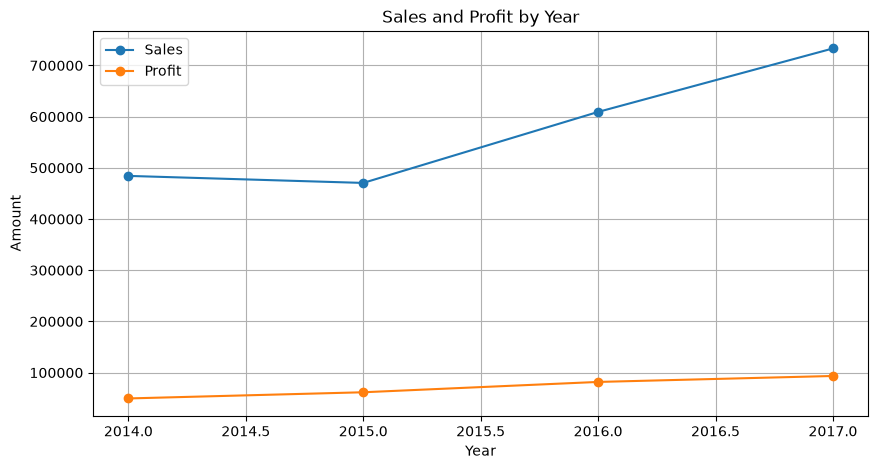

In [23]:
yearly_performance.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Sales and Profit by Year")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

In [24]:
monthly_performance = (
    df.groupby(df["Order Date"].dt.to_period("M"))[["Sales", "Profit"]]
    .sum()
)

monthly_performance.head(12)

,Sales,Profit
Order Date,,
2014-01,14236.8950,2450.1907
2014-02,4519.8920,862.3084
2014-03,55691.0090,498.7299
2014-04,28295.3450,3488.8352
2014-05,23648.2870,2738.7096
2014-06,34595.1276,4976.5244
2014-07,33946.3930,-841.4826
2014-08,27909.4685,5318.1050
2014-09,81777.3508,8328.0994


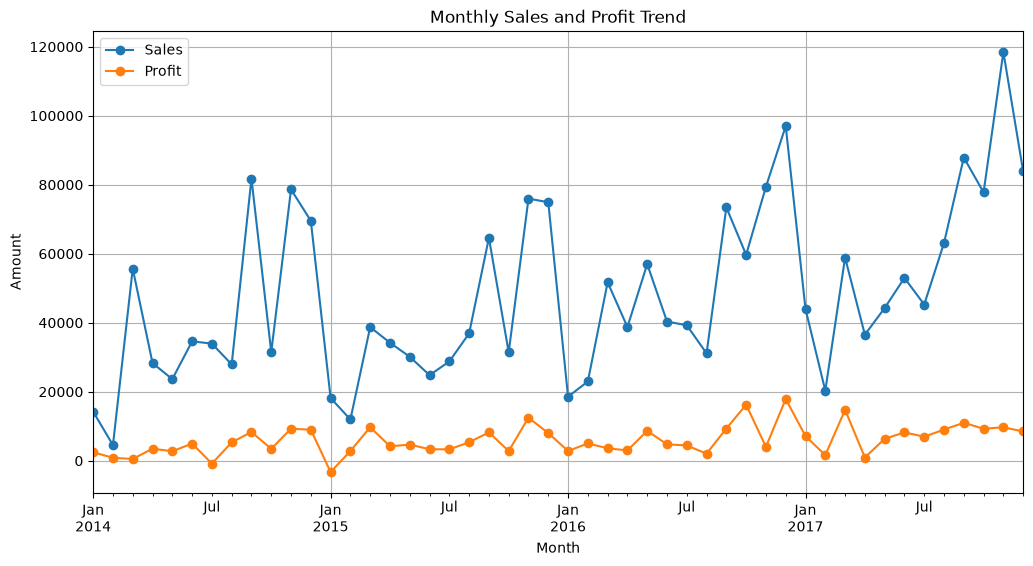

In [25]:
monthly_performance.plot(
    kind="line",
    y=["Sales", "Profit"],
    figsize=(12, 6),
    marker="o"
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

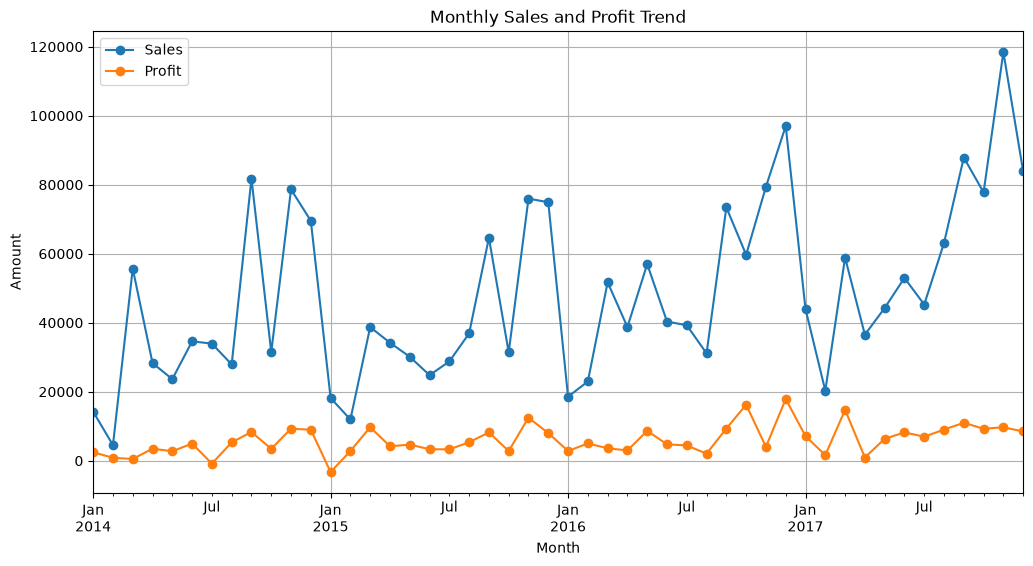

In [26]:
monthly_performance.plot(
    kind="line",
    y=["Sales", "Profit"],
    figsize=(12, 6),
    marker="o"
)

plt.title("Monthly Sales and Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid(True)
plt.show()

In [27]:
correlation_matrix = df[
    ["Sales", "Quantity", "Discount", "Profit"]
].corr()

correlation_matrix

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


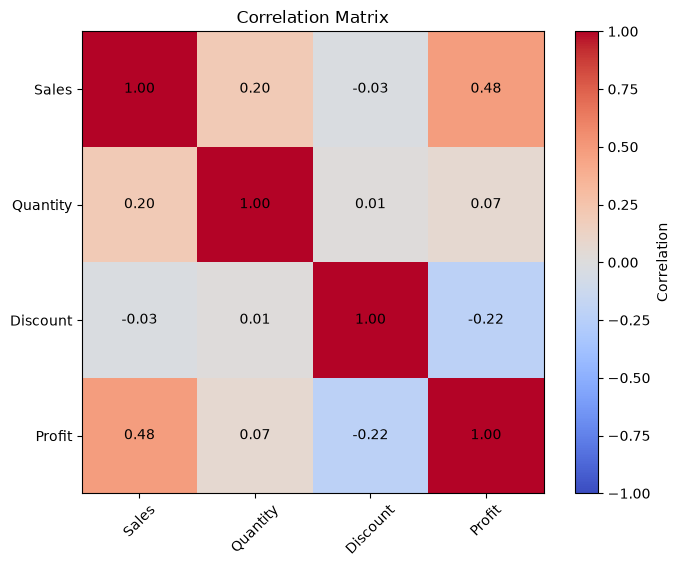

In [29]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.show()

In [30]:
Q1 = df[["Sales", "Profit"]].quantile(0.25)
Q3 = df[["Sales", "Profit"]].quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (
    (df[["Sales", "Profit"]] < (Q1 - 1.5 * IQR)) |
    (df[["Sales", "Profit"]] > (Q3 + 1.5 * IQR))
)

outlier_counts = outlier_mask.sum()

outlier_counts

Sales     1167
Profit    1881
dtype: int64

In [31]:
df.nlargest(10, "Sales")[
    ["Order ID", "Customer Name", "Product Name", "Sales", "Profit"]
]

,Order ID,Customer Name,Product Name,Sales,Profit
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784
6826,CA-2016-118689,Tamara Chand,Canon imageCLASS 2200 Advanced Copier,17499.950,8399.9760
8153,CA-2017-140151,Raymond Buch,Canon imageCLASS 2200 Advanced Copier,13999.960,6719.9808
2623,CA-2017-127180,Tom Ashbrook,Canon imageCLASS 2200 Advanced Copier,11199.968,3919.9888
4190,CA-2017-166709,Hunter Lopez,Canon imageCLASS 2200 Advanced Copier,10499.970,5039.9856
9039,CA-2016-117121,Adrian Barton,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,4946.3700
4098,CA-2014-116904,Sanjit Chand,Ibico EPK-21 Electric Binding System,9449.950,4630.4755
4277,US-2016-107440,Bill Shonely,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,2365.9818
8488,CA-2016-158841,Sanjit Engle,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,2799.9840
6425,CA-2016-143714,Christopher Conant,Canon imageCLASS 2200 Advanced Copier,8399.976,1119.9968


In [32]:
df.nsmallest(10, "Profit")[
    ["Order ID", "Customer Name", "Product Name", "Sales", "Discount", "Profit"]
]

,Order ID,Customer Name,Product Name,Sales,Discount,Profit
7772,CA-2016-108196,Cindy Stewart,Cubify CubeX 3D Printer Double Head Print,4499.985,0.7,-6599.9780
683,US-2017-168116,Grant Thornton,Cubify CubeX 3D Printer Triple Head Print,7999.980,0.5,-3839.9904
9774,CA-2014-169019,Luke Foster,GBC DocuBind P400 Electric Binding System,2177.584,0.8,-3701.8928
3011,CA-2017-134845,Sharelle Roach,Lexmark MX611dhe Monochrome Laser Printer,2549.985,0.7,-3399.9800
4991,US-2017-122714,Henry Goldwyn,Ibico EPK-21 Electric Binding System,1889.990,0.8,-2929.4845
3151,CA-2015-147830,Natalie Fritzler,Cubify CubeX 3D Printer Double Head Print,1799.994,0.7,-2639.9912
5310,CA-2017-131254,Nathan Cano,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,0.8,-2287.7820
9639,CA-2015-116638,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,0.4,-1862.3124
1199,CA-2016-130946,Zuschuss Carroll,GBC DocuBind P400 Electric Binding System,1088.792,0.8,-1850.9464
2697,CA-2014-145317,Sean Miller,Cisco TelePresence System EX90 Videoconferenci...,22638.480,0.5,-1811.0784


In [33]:
df["Profit_Margin"] = (
    df["Profit"] / df["Sales"] * 100
)

df[["Sales", "Profit", "Profit_Margin"]].describe()

,Sales,Profit,Profit_Margin
count,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,12.031393
std,623.245101,234.260108,46.675435
min,0.444000,-6599.978000,-275.000000
25%,17.280000,1.728750,7.500000
50%,54.490000,8.666500,27.000000
75%,209.940000,29.364000,36.250000
max,22638.480000,8399.976000,50.000000


In [34]:
df.nsmallest(10, "Profit_Margin")[
    ["Order ID", "Customer Name", "Product Name",
     "Sales", "Discount", "Profit", "Profit_Margin"]
]

,Order ID,Customer Name,Product Name,Sales,Discount,Profit,Profit_Margin
261,US-2017-155299,Dorris liebe,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624,0.8,-4.4660,-275.0
676,US-2017-119438,Carol Darley,Hoover Portapower Portable Vacuum,2.688,0.8,-7.3920,-275.0
8766,CA-2015-107083,Brenda Bowman,Kensington 6 Outlet SmartSocket Surge Protector,24.588,0.8,-67.6170,-275.0
9164,CA-2015-164007,Maureen Gnade,Hoover Shoulder Vac Commercial Portable Vacuum,143.128,0.8,-393.6020,-275.0
203,US-2017-116701,Logan Currie,Eureka Sanitaire Commercial Upright,66.284,0.8,-178.9668,-270.0
4437,CA-2016-163398,Christy Brittain,Acco Smartsocket Color-Coded Six-Outlet AC Ada...,26.406,0.8,-71.2962,-270.0
4980,US-2016-131114,Rob Williams,Belkin 6 Outlet Metallic Surge Strip,4.356,0.8,-11.7612,-270.0
5414,US-2017-125647,Lena Cacioppo,Euro Pro Shark Stick Mini Vacuum,73.176,0.8,-197.5752,-270.0
5755,CA-2014-163748,Hunter Glantz,Hoover Replacement Belts For Soft Guard & Comm...,3.160,0.8,-8.5320,-270.0
6034,US-2015-155369,Patrick Gardner,"Fellowes Premier Superior Surge Suppressor, 10...",19.568,0.8,-52.8336,-270.0


In [35]:
discount_profit = (
    df.groupby("Discount")["Profit"]
    .sum()
)

discount_profit

Discount
0.00    320987.6032
0.10      9029.1770
0.15      1418.9915
0.20     90337.3060
0.30    -10369.2774
0.32     -2391.1377
0.40    -23057.0504
0.45     -2493.1111
0.50    -20506.4281
0.60     -5944.6552
0.70    -40075.3569
0.80    -30539.0392
Name: Profit, dtype: float64

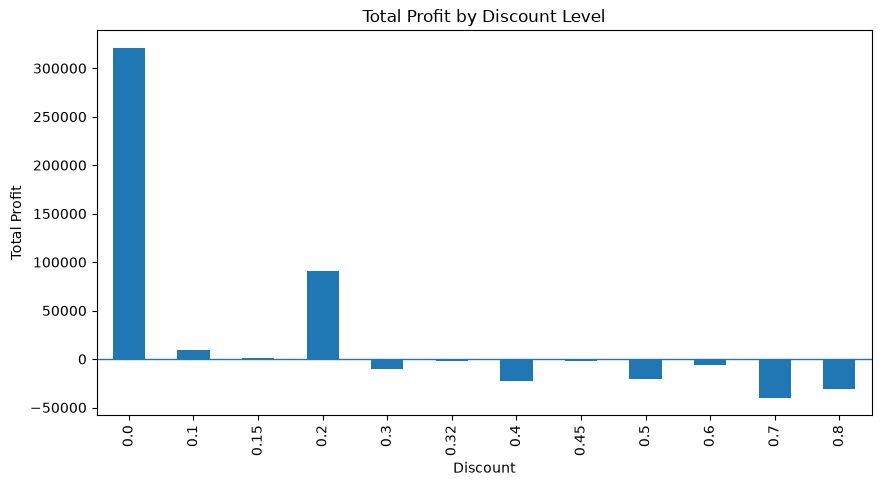

In [36]:
discount_profit.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Total Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.axhline(0, linewidth=1)
plt.show()

In [37]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Total Customers: 793


In [38]:
category_summary = (
    df.groupby("Category")[["Sales", "Profit"]]
    .sum()
)

category_summary["Profit_Margin"] = (
    category_summary["Profit"] /
    category_summary["Sales"] * 100
)

category_summary.sort_values("Profit", ascending=False)

,Sales,Profit,Profit_Margin
Category,,,
Technology,836154.0330,145454.9481,17.395712
Office Supplies,719047.0320,122490.8008,17.035158
Furniture,741999.7953,18451.2728,2.486695


In [39]:
subcategory_summary = (
    df.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
)

subcategory_summary["Profit_Margin"] = (
    subcategory_summary["Profit"] /
    subcategory_summary["Sales"] * 100
)

subcategory_summary.sort_values("Profit")

,Sales,Profit,Profit_Margin
Sub-Category,,,
Tables,206965.5320,-17725.4811,-8.564460
Bookcases,114879.9963,-3472.5560,-3.022768
Supplies,46673.5380,-1189.0995,-2.547695
Fasteners,3024.2800,949.5182,31.396504
Machines,189238.6310,3384.7569,1.788618
Labels,12486.3120,5546.2540,44.418672
Art,27118.7920,6527.7870,24.071083
Envelopes,16476.4020,6964.1767,42.267582
Furnishings,91705.1640,13059.1436,14.240358


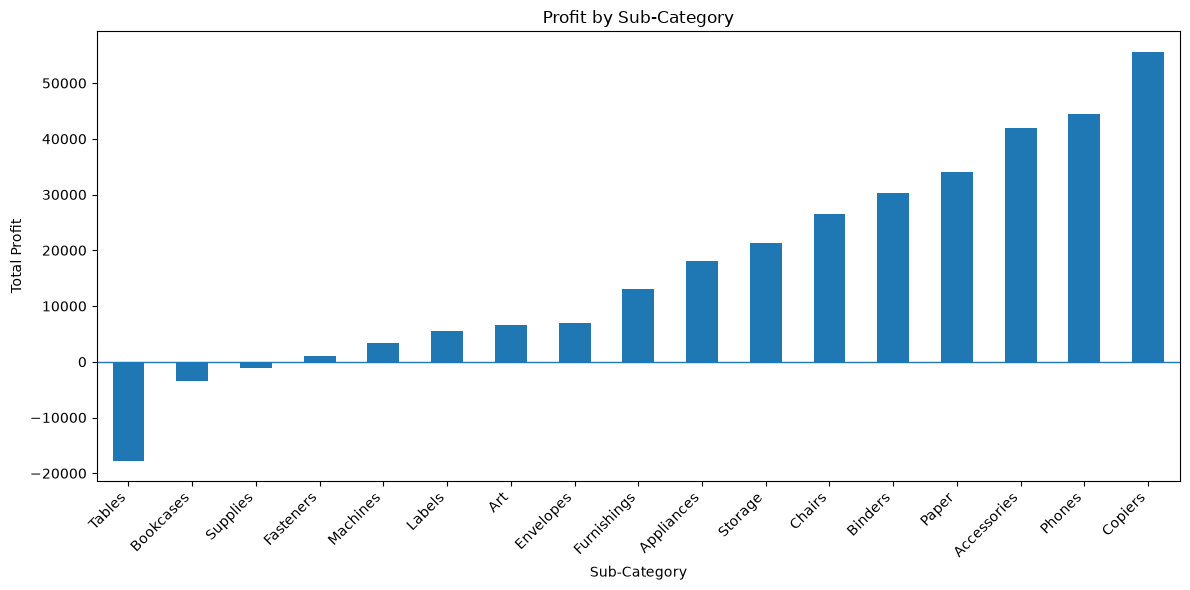

In [40]:
subcategory_summary["Profit"].sort_values().plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

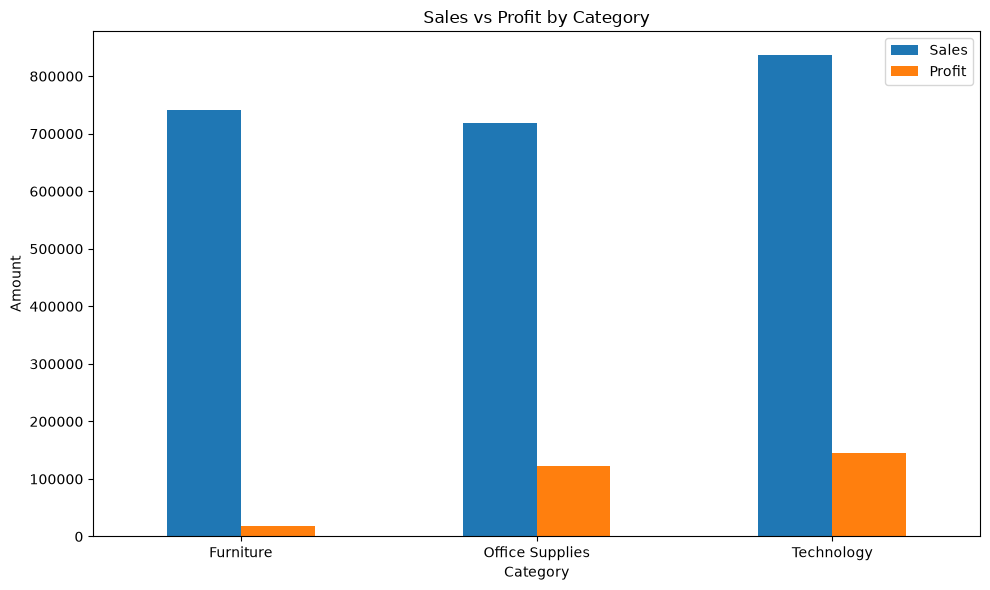

In [41]:
category_summary[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend(["Sales", "Profit"])
plt.tight_layout()
plt.show()

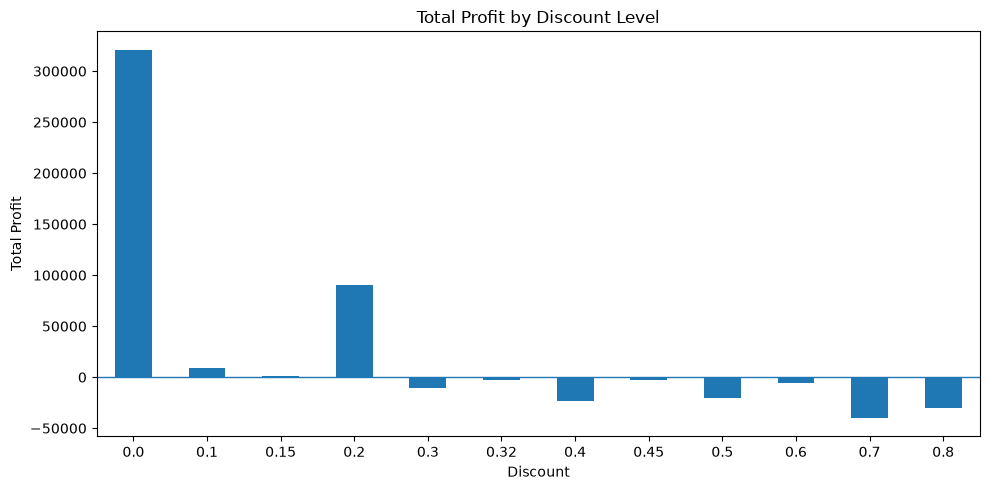

In [42]:
discount_profit.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Total Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Key Business Insights

- Total sales were approximately $2.30M, generating $286.4K in total profit across 5,009 orders and 793 customers.
- Technology generated the highest total profit at approximately $145.5K with a 17.4% profit margin.
- Furniture generated $742K in sales but only $18.5K in profit, resulting in a much lower 2.5% profit margin.
- Tables were the most unprofitable sub-category, generating approximately $17.7K in losses and a -8.6% profit margin.
- Higher discount levels were associated with lower profitability. Total profit became negative at several discount levels of 30% and above.
- Sales and profit showed a moderate positive correlation (0.48), while discount and profit showed a negative correlation (-0.22).
- Several high-value transactions generated negative profit, showing that large sales do not necessarily translate into profitable transactions.
- Overall sales and profit increased from 2014 to 2017, although annual sales and profitability did not always move in the same direction.

## Business Recommendations

- Review discount policies for high-discount transactions, especially discounts of 30% or more.
- Investigate the profitability of the Tables, Bookcases, and Supplies sub-categories.
- Review high-value orders with negative profit before using sales volume as a performance measure.
- Monitor Furniture profitability because the category generates substantial sales but has a much lower margin than Technology and Office Supplies.
- Use both Sales and Profit Margin when evaluating products, customers, and categories.
- Consider setting profitability thresholds or approval rules for heavily discounted transactions.